# Homework 6
Nicole Ton <br>
April 2026 <br>

Jessie, we should have been better students and started this homework earlier. However, working together has really strengthened our bond as friends. Thank you to Brayan and Suyash and Harrison and Riddhi and Wynter and Mateo and Sebastian for helping me with this homework. Hopefully, you can understand this:)

---
## Contents
* [Import Block](#import)
* [Directories](#directories)
* [Question 1](#q1)
* [Question 2](#q2)
* [Question 3](#q3)
* [Question 4](#q4)
* [Question 5](#q5)
* [Question 6](#q6)
* [Question 7](#q7)

---
### Import Block <a class="anchor" id="import"></a>

In [607]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib import rc
%matplotlib inline
from astropy.visualization import hist
from ccdproc import ImageFileCollection, Combiner
import ccdproc as ccdp
from astropy.modeling import fitting
from astropy.modeling.models import Polynomial1D,Chebyshev1D,Legendre1D,Hermite1D
from astropy.nddata import CCDData
from datetime import datetime
from astropy.stats import sigma_clip, mad_std, sigma_clipped_stats
from astropy.visualization import ZScaleInterval, hist
from astropy import units as u
import os
import glob
from photutils.aperture import CircularAperture,CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.detection import DAOStarFinder
from astropy.table import Table
from astropy.coordinates import SkyCoord

In [2]:
# import convenience plotting functions downloaded from 
# here: https://github.com/mwcraig/ccd-reduction-and-photometry-guide
phot_tutorial_dir = '/Users/ngoc/Documents/8060/astr_8060_s26/work/nngocton03/notebooks/convenience_functions.py'
import sys
sys.path.insert(0,phot_tutorial_dir)
from convenience_functions import show_image

In [3]:
# style guide
plt.style.use('/Users/ngoc/Documents/8060/astr_8060_s26/work/nngocton03/notebooks/guide.mplstyle')

# set a couple more default parameters for the plots below
rc('font', size=20)
rc('axes', grid=True)

### Directories <a class="anchor" id="directories"></a>

In [4]:
# data directory
data_dir = "/Users/ngoc/Documents/8060/Imaging/"

# output directory
reduced_dir = "/Users/ngoc/Documents/8060/astr_8060_s26/work/nngocton03/notebooks/reduced/"

### Helper Functions <a class="anchor" id="hf"></a>

Shoutout Suyash!

In [5]:
def subtract_and_trim(image_file):
    data, header = fits.getdata(image_file, header=True)
    ccd = CCDData(data, unit=u.adu, meta=header)
    os = CCDData(np.concatenate((ccd.data[:, :53], ccd.data[:, 2101:]), axis=1), unit=ccd.unit)
    data_o = ccdp.subtract_overscan(ccd, overscan = os, overscan_axis = 1, model = Polynomial1D(degree=3))
    data_ot = ccdp.trim_image(data_o[:, 53:2101])
    fits.writeto(reduced_dir+image_file.split("/")[-1].split(".")[0]+"_ot.fits", data_ot, header, overwrite=True)
    return data_ot

def make_master_bias(bias_files):
    bias_data = []
    for file in bias_files:
        bias_data.append(subtract_and_trim(file))
    master_bias = ccdp.combine(bias_data, reduced_dir+'master_bias.fits', method = 'average', overwrite_output=True)
    fits.writeto(reduced_dir+"master_bias.fits", master_bias, fits.getheader(bias_files[0]), overwrite=True)
    return master_bias

def bias_subtract(file, master_bias):
    data_ot = subtract_and_trim(file)
    data_otz = data_ot.subtract(master_bias)
    header = fits.getheader(file)
    fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"_otz.fits", data_otz, header, overwrite=True)

def bias_subtract_many_filters(d, master_bias):
    for filter in d:
        for file in d[filter]:
            bias_subtract(file, master_bias)

def make_master_dark(dark_files, master_bias):
    dark_data_list = []
    for file in dark_files:
        header = fits.getheader(file)
        dark_data = subtract_and_trim(file)
        dark_data_z = dark_data.subtract(master_bias)
        dark_data_list.append(dark_data_z)
        fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"_otz.fits", dark_data_z, header, overwrite=True)
    master_dark = ccdp.combine(dark_data_list, unit='adu', method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)
    fits.writeto(reduced_dir+"master_dark.fits", master_dark, header, overwrite=True)
    return master_dark

def dark_subtract(file, master_dark):
    data, header = fits.getdata(file, header=True)
    ccd = CCDData(data, unit=u.adu, meta=header)
    data_otzd = ccdp.subtract_dark(ccd, master_dark, exposure_time="EXPTIME", exposure_unit=u.second)
    fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"d.fits", data_otzd, header, overwrite=True)

def dark_subtract_many_filters(d, master_dark):
    for filter in d:
        for file in d[filter]:
            dark_subtract(file, master_dark)

def make_master_flats(flat_files):
    master_flats = {}
    for filter in flat_files:
        flat_data = []
        for flat in flat_files[filter]:
            flat_data.append(fits.getdata(flat))
        flat_mean = np.mean(np.mean(flat_data, axis=1), axis=1)
        average_flat_mean = np.mean(flat_mean)
        scaled_flats = []
        
        for i, flat in enumerate(flat_data):
            scaled_flats.append(flat * average_flat_mean / flat_mean[i])

        scaled_ccds = [CCDData(flat, unit=u.adu) for flat in scaled_flats]
        master_flat = ccdp.combine(scaled_ccds, unit='adu', method='median', sigma_clip=False)
        fits.writeto(reduced_dir+f"master_flat_{filter}.fits", master_flat, fits.getheader(flat_files[filter][0]), overwrite=True)
        master_flats[filter] = master_flat
    return master_flats

def flat_fielding(science_files, norm_master_flats):
    for filter in science_files:
        for file in science_files[filter]:
            data, header = fits.getdata(file, header=True)
            data_f = data/norm_master_flats[filter]
            fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"f.fits", data_f, header, overwrite=True)

In [19]:
img_files = np.sort(glob.glob(data_dir+"a*[0-9].fits"))
dark_files = np.sort(glob.glob(data_dir+"d*.fits"))
linear_files = np.sort(glob.glob(data_dir+"a07[4-9].fits") + glob.glob(data_dir+"a080.fits"))

bias_files = img_files[92:111]
# make_master_bias(bias_files)
master_bias_data, master_bias_header = fits.getdata(reduced_dir+"master_bias.fits", header=True)
master_bias = CCDData(master_bias_data, unit=u.adu, meta=master_bias_header)

# make_master_dark(dark_files, master_bias)
master_dark_data, master_dark_header = fits.getdata(reduced_dir+"master_dark.fits", header=True)
master_dark = CCDData(master_dark_data, unit=u.adu, meta=master_dark_header)

### Files <a class="anchor" id="files"></a>

In [162]:
otz_files = np.sort(glob.glob(reduced_dir+"a*_otz.fits"))

flat_files = {}
flat_files["U"] = otz_files[16:24]
flat_files["B"] = otz_files[24:38]
flat_files["V"] = otz_files[38:45]
flat_files["R"] = otz_files[45:51]
flat_files["I"] = otz_files[52:58]

PG1633_files = {}
PG1633_files["U"] = np.concatenate((otz_files[75:77], otz_files[106:108], otz_files[-20:-18], otz_files[-10:-8]))
PG1633_files["B"] = np.concatenate((otz_files[77:79], otz_files[108:110], otz_files[-18:-16], otz_files[-8:-6]))
PG1633_files["V"] = np.concatenate((otz_files[79:81], otz_files[110:112], otz_files[-16:-14], otz_files[-6:-4]))
PG1633_files["R"] = np.concatenate((otz_files[81:83], otz_files[112:114], otz_files[-14:-12], otz_files[-4:-2]))
PG1633_files["I"] = np.concatenate((otz_files[83:85], otz_files[114:116], otz_files[135:137], otz_files[-2:]))

NGC6823_files = {}
NGC6823_files["U"] = otz_files[125:127]
NGC6823_files["B"] = otz_files[123:125]
NGC6823_files["V"] = otz_files[120:123]
NGC6823_files["R"] = otz_files[118:120]
NGC6823_files["I"] = otz_files[116:118]

In [13]:
master_flats = make_master_flats(flat_files)

norm_master_flats = {}
for filter in master_flats:
    flat_mean = np.mean(master_flats[filter].data)
    norm_master_flats[filter] = np.array(master_flats[filter]/flat_mean)

In [163]:
flat_fielding(PG1633_files, norm_master_flats)
flat_fielding(NGC6823_files, norm_master_flats)

In [347]:
otzf_files = np.sort(glob.glob(reduced_dir+"a***_otzf.fits"))

ngc_files = otzf_files[53:64].copy()

In [374]:
pg_files = {}
pg_files["U"] = np.concatenate((otzf_files[33:35], otzf_files[43:45], otzf_files[64:66], otzf_files[74:76]))
pg_files["B"] = np.concatenate((otzf_files[35:37], otzf_files[45:47], otzf_files[66:68], otzf_files[76:78]))
pg_files["V"] = np.concatenate((otzf_files[37:39], otzf_files[47:49], otzf_files[68:70], otzf_files[78:80]))
pg_files["R"] = np.concatenate((otzf_files[39:41], otzf_files[49:51], otzf_files[70:72], otzf_files[80:82]))
pg_files["I"] = np.concatenate((otzf_files[41:43], otzf_files[51:53], otzf_files[72:74], otzf_files[82:84]))

## Question 1 <a class="anchor" id="q1"></a>
Testing the linearity of the CCD

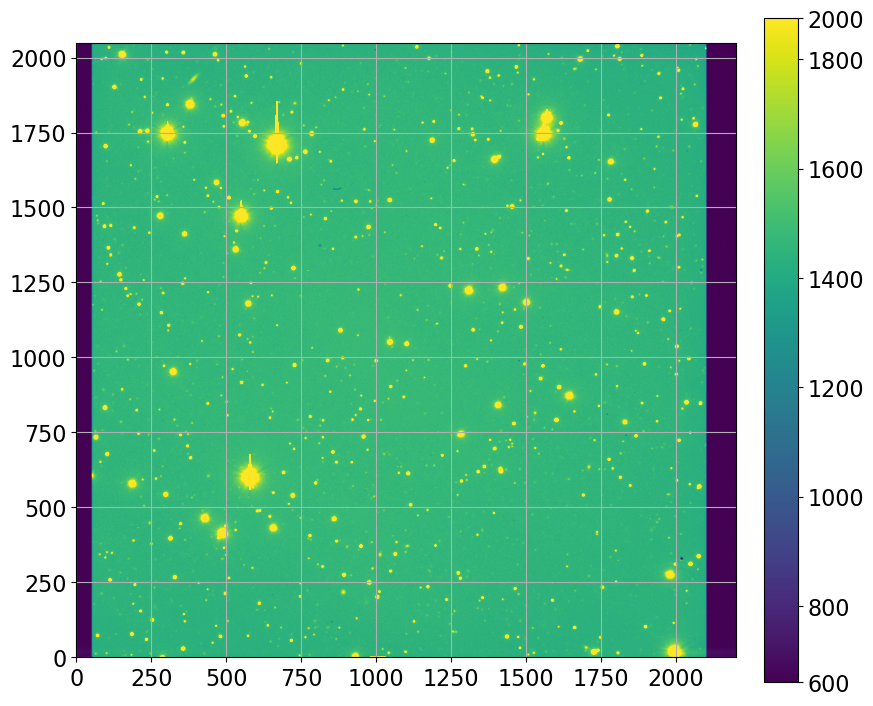

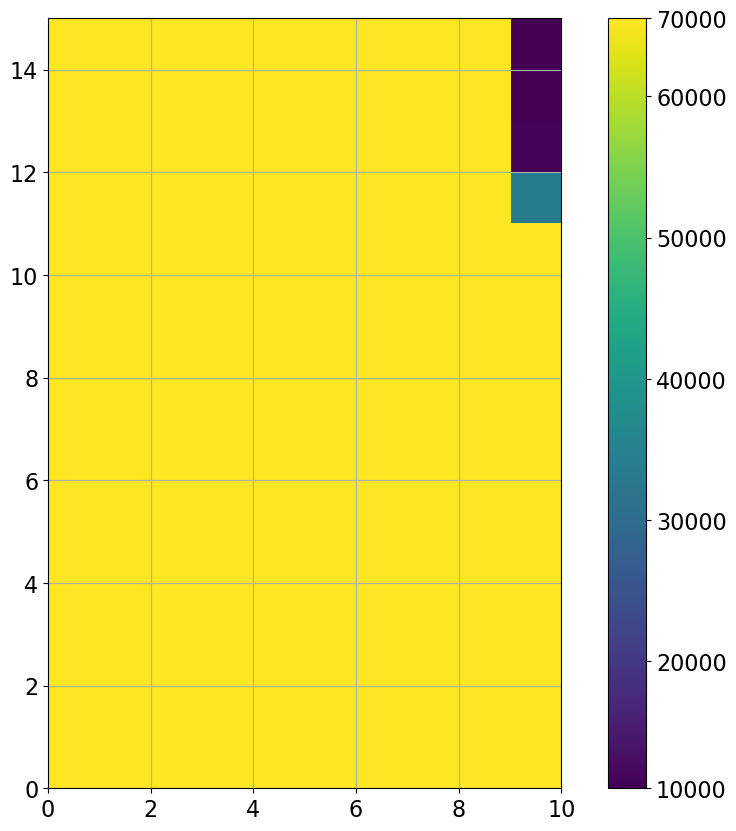

In [188]:
img = fits.getdata(linear_files[-1])
show_image(img)
show_image(img[1710: 1725, 665:675])

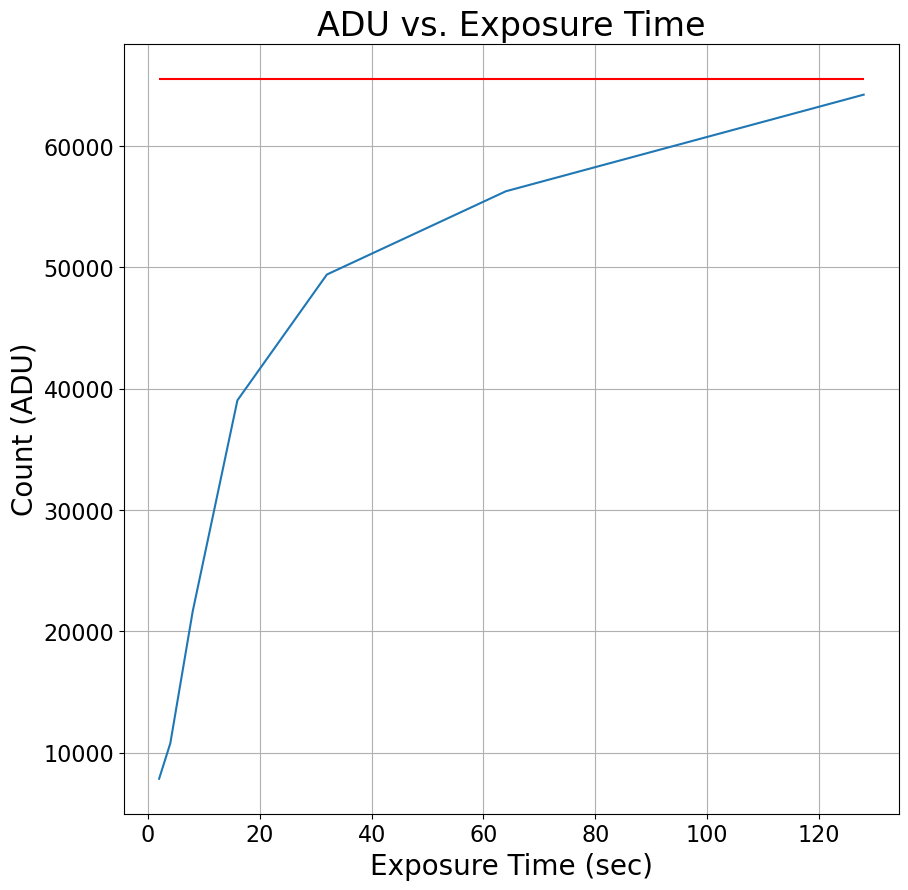

In [187]:
mean_count = []
exp_time = []

for file in linear_files:
    data, header = fits.getdata(file, header=True)
    mean_count.append(data[1710: 1725, 665:675].mean())
    exp_time.append(header["EXPTIME"])

plt.plot(exp_time, mean_count)
plt.hlines(y=(2**16), xmin=exp_time[0], xmax=exp_time[-1], color="red")
plt.xlabel("Exposure Time (sec)")
plt.ylabel("Count (ADU)")
plt.title("ADU vs. Exposure Time")
plt.show()

It's not quite linear, but it does reach up to the 2^16 ADU limit.

## Question 2 <a class="anchor" id="q2"></a>

In [ ]:
data = fits.getdata(pg_files["U"][4])
aper_rad = np.array([1, 2, 3, 4, 5, 7, 10, 15, 20])
aper_area = np.array([np.pi*(r**2) for r in aper_rad])

# bright, medium, faint
x1, x2, x3 = 535.84613, 644.4979, 490.46718
y1, y2, y3 = 418.10389, 1671.4912, 1917.5561
pos = [(x1, y1), (x2, y2), (x3, y3)]

apertures = [CircularAperture(pos, r=r) for r in aper_rad]
annulus_aperture = CircularAnnulus(pos, r_in=20, r_out=30)
annulus_area = np.pi * ((30**2) - (25**2))
aper_phot_table = aperture_photometry(data, apertures)
annul_phot_table = aperture_photometry(data, annulus_aperture)["aperture_sum"]
    
sigma_rn = 13.787429250579269 / 1.6104514889194042

In [282]:
def signal_to_noise(s, b, area_source):
    bg = (b / annulus_area) * area_source
    sigma_b = s / annulus_area

    return (s-bg) / np.sqrt((s-bg) + area_source*((sigma_b**2)+(sigma_rn**2)))

In [289]:
bright_snr = []
med_snr = []
faint_snr = []

for i, col in enumerate(aper_phot_table.colnames[3:]):
    bright_snr.append(signal_to_noise(aper_phot_table[col][0], annul_phot_table[0], aper_area[i]))
    med_snr.append(signal_to_noise(aper_phot_table[col][1], annul_phot_table[1], aper_area[i]))
    faint_snr.append(signal_to_noise(aper_phot_table[col][2], annul_phot_table[2], aper_area[i]))

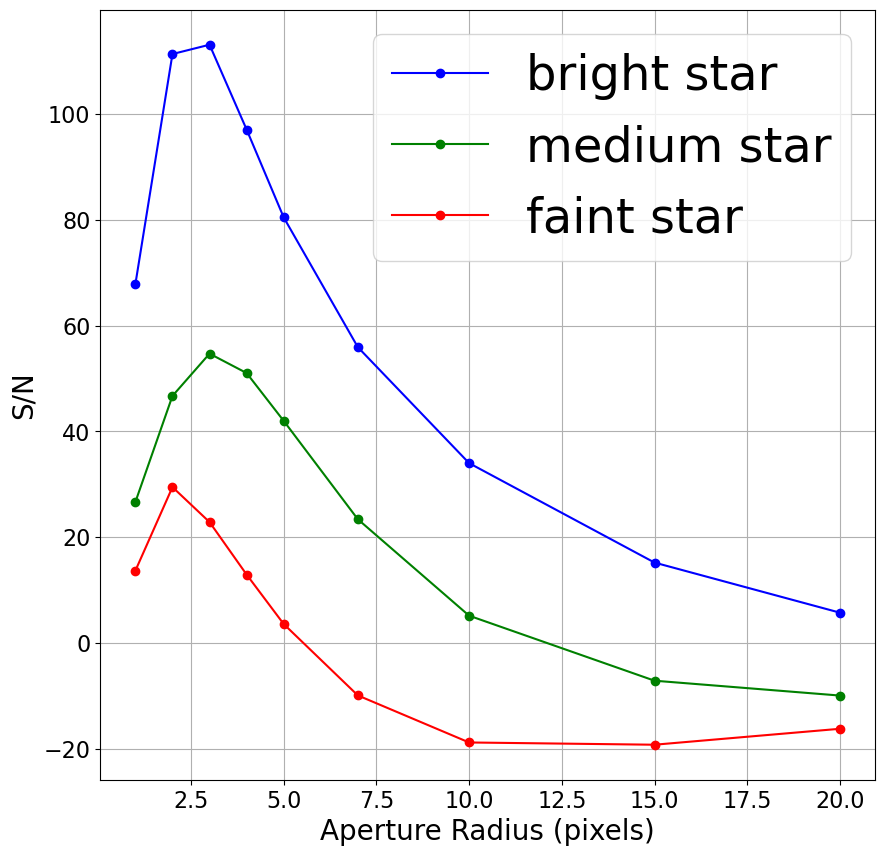

In [296]:
plt.plot(aper_rad, bright_snr, color="blue", label="bright star", marker="o")
plt.plot(aper_rad, med_snr, color="green", label="medium star", marker="o")
plt.plot(aper_rad, faint_snr, color="red", label="faint star", marker="o")
plt.legend()
plt.xlabel("Aperture Radius (pixels)")
plt.ylabel("S/N")
plt.show()

From my plot, it looks like an aperture radius of 3 will be best.

## Question 3 <a class="anchor" id="q3"></a>

In [308]:
# A, B, C, D
std_field_pos = [(1047.3473, 1043.4231), (1254.1665, 1222.1547), (1366.3725, 1231.5985), (1446.6645, 1182.5061)]

<img src="/Users/ngoc/Documents/8060/astr_8060_s26/work/nngocton03/notebooks/std_stars.png" width="400" height="400">
<img src="/Users/ngoc/Documents/8060/astr_8060_s26/work/nngocton03/notebooks/std_field_stars.png" width="400" height="400>

## Question 4 <a class="anchor" id="q4"></a>
From the apertures.ipynb, the instrumental magnitude equation is given as:

$m = -2.5\times\textrm{log}(S) = -2.5\times\textrm{log}(T-AB)$

where S is the total signal from the source in the aperture, A is the total number of background signals, B is the average background signal per pixel, and T is the total signal in the aperture.

In [311]:
def get_inst_mag(t, a, bg, bg_area):
    b = bg / bg_area
    return -2.5 * np.log10(t - (a*b))

In [378]:
inst_mag = []
data, header = fits.getdata(pg_files["U"][1], header=True)  # a082

for star in std_field_pos:
    aperture = CircularAperture(star, r=3)
    annulus = CircularAnnulus(star, r_in=25, r_out=30)
    source = aperture_photometry(data, aperture)["aperture_sum"]
    background = aperture_photometry(data, annulus)["aperture_sum"]
    inst_mag.append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))

print(inst_mag)

[-9.66336872095035, -11.006928911016233, -10.63019407037666, -11.744055742983019]


## Question 5 <a class="anchor" id="q5"></a>

$\chi = 1.18, 1.24, 1.51, 2.20$ 

In [462]:
chi_vals = np.array([1.18, 1.24, 1.51, 2.20])

In [385]:
# U
# 82, 130, 202, 237

pg_u_files = [pg_files["U"][1], pg_files["U"][2], pg_files["U"][4], pg_files["U"][6]]
pg_files["U_shift"] = [(0, 0), (-57, -6), (-67,-12), (-154,-9)]
a_u_inst = []
b_u_inst = []
c_u_inst = []
d_u_inst = []
pg_files["U_inst"] = [a_u_inst, b_u_inst, c_u_inst, d_u_inst]

In [408]:
for i, star in enumerate(std_field_pos):
    for ii, file in enumerate(pg_u_files):
        data, header = fits.getdata(file, header=True)
        old_x = star

        new_x = old_x[0] + pg_files["U_shift"][ii][0]
        new_y = old_x[1] + pg_files["U_shift"][ii][1]

        aperture = CircularAperture(positions=(new_x, new_y), r=3)
        annulus = CircularAnnulus(positions=(new_x, new_y), r_in=25, r_out=30)
        source = aperture_photometry(data, aperture)["aperture_sum"]
        background = aperture_photometry(data, annulus)["aperture_sum"]
        pg_files["U_inst"][i].append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))
    

In [411]:
# B
# 83, 132, 204, 239

pg_b_files = [pg_files["B"][0], pg_files["B"][2], pg_files["B"][4], pg_files["B"][6]]
pg_files["B_shift"] = [(-1, 0), (-59, -5), (-65, -12), (-153, -10)]
a_b_inst = []
b_b_inst = []
c_b_inst = []
d_b_inst = []
pg_files["B_inst"] = [a_b_inst, b_b_inst, c_b_inst, d_b_inst]

In [412]:
for i, star in enumerate(std_field_pos):
    for ii, file in enumerate(pg_b_files):
        data, header = fits.getdata(file, header=True)
        old_x = star

        new_x = old_x[0] + pg_files["B_shift"][ii][0]
        new_y = old_x[1] + pg_files["B_shift"][ii][1]

        aperture = CircularAperture(positions=(new_x, new_y), r=3)
        annulus = CircularAnnulus(positions=(new_x, new_y), r_in=25, r_out=30)
        source = aperture_photometry(data, aperture)["aperture_sum"]
        background = aperture_photometry(data, annulus)["aperture_sum"]
        pg_files["B_inst"][i].append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))

In [413]:
# V
# 86, 134, 206, 241

pg_v_files = [pg_files["V"][1], pg_files["V"][2], pg_files["V"][4], pg_files["V"][6]]
pg_files["V_shift"] = [(-3, 1), (-59, -5), (-66, -9), (-152, -9)]
a_v_inst = []
b_v_inst = []
c_v_inst = []
d_v_inst = []
pg_files["V_inst"] = [a_v_inst, b_v_inst, c_v_inst, d_v_inst]

In [414]:
for i, star in enumerate(std_field_pos):
    for ii, file in enumerate(pg_v_files):
        data, header = fits.getdata(file, header=True)
        old_x = star

        new_x = old_x[0] + pg_files["V_shift"][ii][0]
        new_y = old_x[1] + pg_files["V_shift"][ii][1]

        aperture = CircularAperture(positions=(new_x, new_y), r=3)
        annulus = CircularAnnulus(positions=(new_x, new_y), r_in=25, r_out=30)
        source = aperture_photometry(data, aperture)["aperture_sum"]
        background = aperture_photometry(data, annulus)["aperture_sum"]
        pg_files["V_inst"][i].append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))

In [415]:
# R
# 87, 136, 208, 243

pg_r_files = [pg_files["R"][0], pg_files["R"][2], pg_files["R"][4], pg_files["R"][6]]
pg_files["R_shift"] = [(-2, 2), (-59, -5), (-66, -9), (-153, -8)]
a_r_inst = []
b_r_inst = []
c_r_inst = []
d_r_inst = []
pg_files["R_inst"] = [a_r_inst, b_r_inst, c_r_inst, d_r_inst]

In [416]:
for i, star in enumerate(std_field_pos):
    for ii, file in enumerate(pg_r_files):
        data, header = fits.getdata(file, header=True)
        old_x = star

        new_x = old_x[0] + pg_files["R_shift"][ii][0]
        new_y = old_x[1] + pg_files["R_shift"][ii][1]

        aperture = CircularAperture(positions=(new_x, new_y), r=3)
        annulus = CircularAnnulus(positions=(new_x, new_y), r_in=25, r_out=30)
        source = aperture_photometry(data, aperture)["aperture_sum"]
        background = aperture_photometry(data, annulus)["aperture_sum"]
        pg_files["R_inst"][i].append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))

In [417]:
# I
# 89, 138, 210, 245

pg_i_files = [pg_files["I"][0], pg_files["I"][2], pg_files["I"][4], pg_files["I"][6]]
pg_files["I_shift"] = [(-4, 2), (-60, -4), (-67, -10), (-152, -8)]
a_i_inst = []
b_i_inst = []
c_i_inst = []
d_i_inst = []
pg_files["I_inst"] = [a_i_inst, b_i_inst, c_i_inst, d_i_inst]

In [418]:
for i, star in enumerate(std_field_pos):
    for ii, file in enumerate(pg_i_files):
        data, header = fits.getdata(file, header=True)
        old_x = star

        new_x = old_x[0] + pg_files["I_shift"][ii][0]
        new_y = old_x[1] + pg_files["I_shift"][ii][1]

        aperture = CircularAperture(positions=(new_x, new_y), r=3)
        annulus = CircularAnnulus(positions=(new_x, new_y), r_in=25, r_out=30)
        source = aperture_photometry(data, aperture)["aperture_sum"]
        background = aperture_photometry(data, annulus)["aperture_sum"]
        pg_files["I_inst"][i].append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))

In [529]:
std_stars = ["A", "B", "C", "D"]

# Landolt magnitudes
# V-band manitudes
V_A = 15.256
V_B = 12.969
V_C = 13.229
V_D = 13.691

# U, B, V, R, I
landolt_mag = {}
star_A = [0.32+(0.873+V_A), 0.873+V_A, V_A, V_A-(0.505), V_A-(1.015)]
star_B = [1.007+(1.081+V_B), 1.081+V_B, V_B, V_B-(0.590), V_B-(1.090)]
star_C = [1.138+(1.134+V_C), 1.134+V_C, V_C, V_C-(0.618), V_C-(1.138)]
star_D = [-0.025+(0.535+V_D), 0.535+V_D, V_D, V_D-(0.324), V_D-(0.650)]
landolt_mag["U"] = [star_A[0], star_B[0], star_C[0], star_D[0]]
landolt_mag["B"] = [star_A[1], star_B[1], star_C[1], star_D[1]]
landolt_mag["V"] = [star_A[2], star_B[2], star_C[2], star_D[2]]
landolt_mag["R"] = [star_A[3], star_B[3], star_C[3], star_D[3]]
landolt_mag["I"] = [star_A[4], star_B[4], star_C[4], star_D[4]]

# extinction coefficients: m, b
pg_files["U_ex"] = []
pg_files["B_ex"] = []
pg_files["V_ex"] = []
pg_files["R_ex"] = []
pg_files["I_ex"] = []

From the way I've written my code, I did the linear fit for each standard field star, so I ended up taking the mean of the m and b values since they were so close to each other.

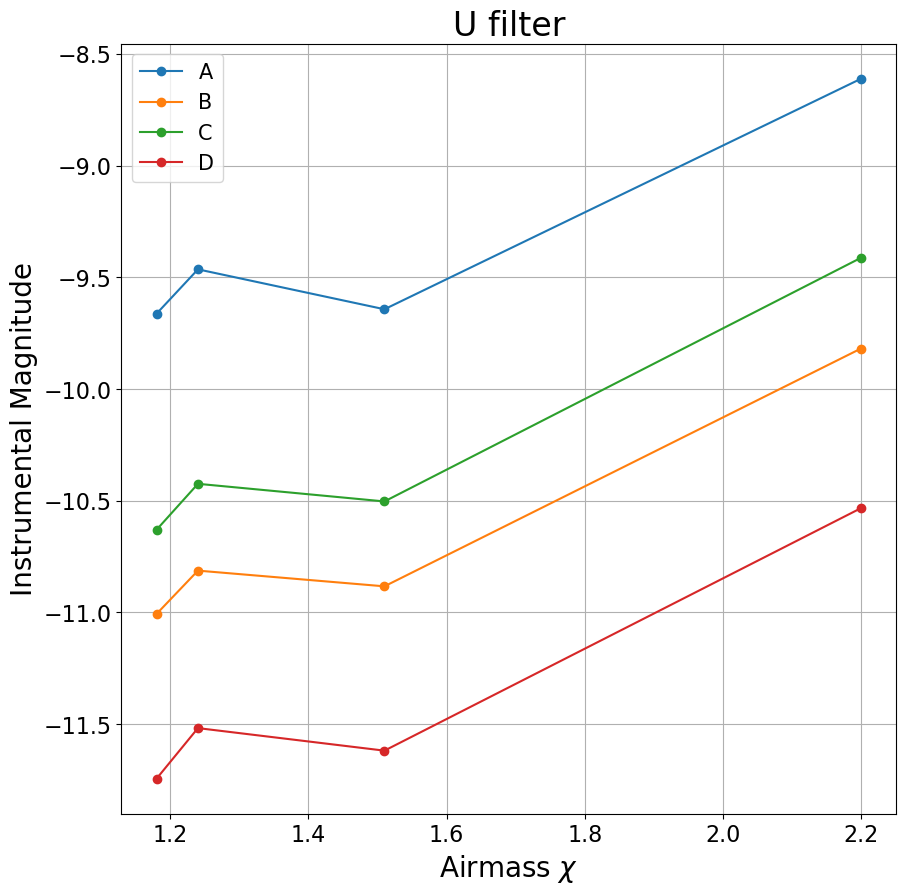

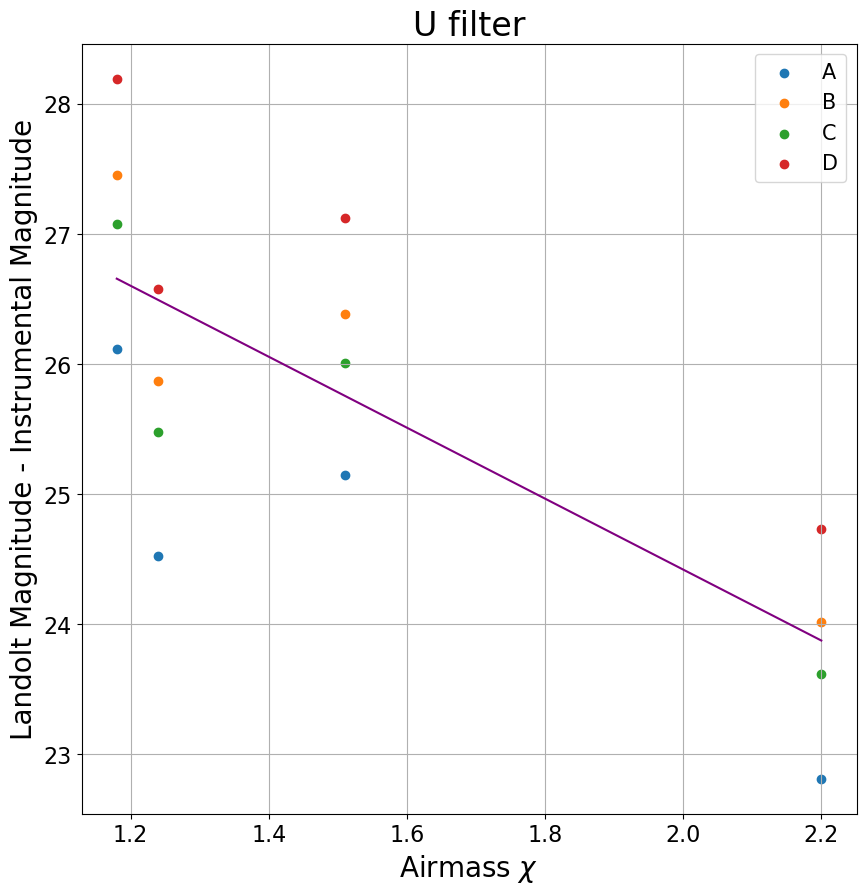

In [530]:
for i, star in enumerate(pg_files["U_inst"]):
    plt.plot(chi_vals, star, label=std_stars[i], marker="o")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Instrumental Magnitude")
plt.title("U filter")
plt.legend(fontsize=15)
plt.show()

m_mean, b_mean = [], []
delta_m = []
for i, star in enumerate(pg_files["U_inst"]):
    plt.scatter(chi_vals, np.array(landolt_mag["U"])-np.array(star), label=std_stars[i], marker="o")
    m, b = np.polyfit(chi_vals, np.array(landolt_mag["U"])-np.array(star), deg=1)
    m_mean.append(m)
    b_mean.append(b)
y = np.mean(m_mean)*(chi_vals) + np.mean(b_mean)
pg_files["U_ex"].append(np.mean(m_mean))
pg_files["U_ex"].append(np.mean(b_mean))
plt.plot(chi_vals, y, color="purple")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Landolt Magnitude - Instrumental Magnitude")
plt.title("U filter")
plt.legend(fontsize=15)
plt.show()


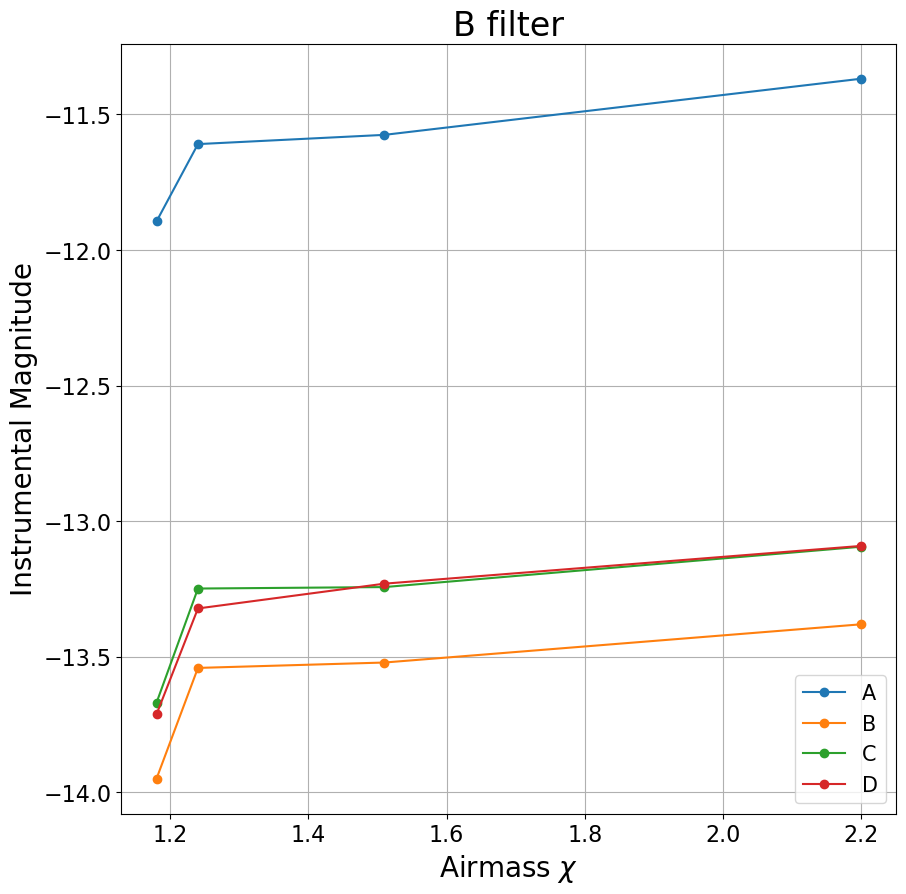

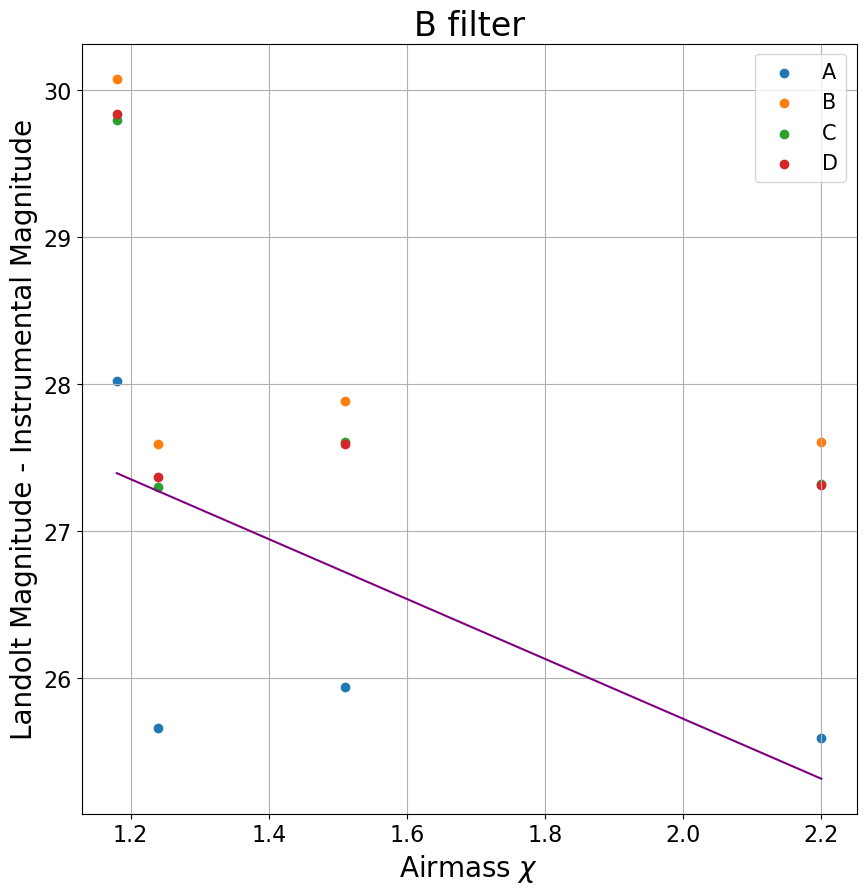

In [531]:
for i, star in enumerate(pg_files["B_inst"]):
    plt.plot(chi_vals, star, label=std_stars[i], marker="o")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Instrumental Magnitude")
plt.title("B filter")
plt.legend(fontsize=15)
plt.show()

for i, star in enumerate(pg_files["B_inst"]):
    plt.scatter(chi_vals, np.array(landolt_mag["B"])-np.array(star), label=std_stars[i], marker="o")
    m, b = np.polyfit(chi_vals, np.array(landolt_mag["B"])-np.array(star), deg=1)
    m_mean.append(m)
    b_mean.append(b)
y = np.mean(m_mean)*(chi_vals) + np.mean(b_mean)
pg_files["B_ex"].append(np.mean(m_mean))
pg_files["B_ex"].append(np.mean(b_mean))
plt.plot(chi_vals, y, color="purple")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Landolt Magnitude - Instrumental Magnitude")
plt.title("B filter")
plt.legend(fontsize=15)
plt.show()


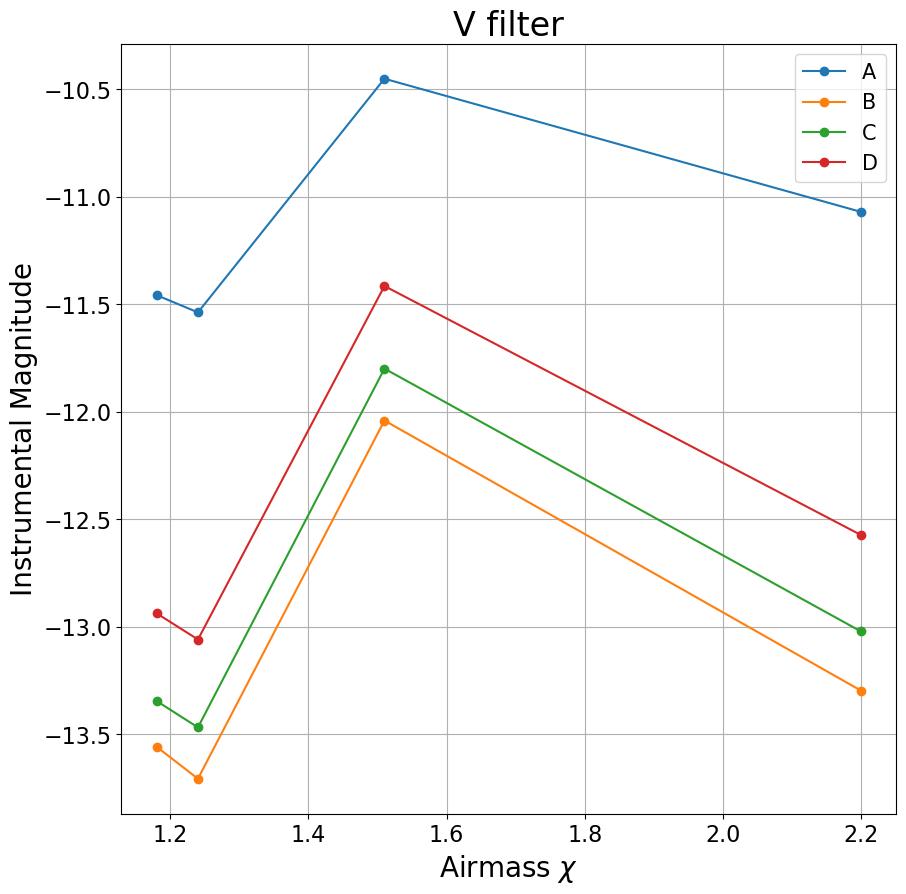

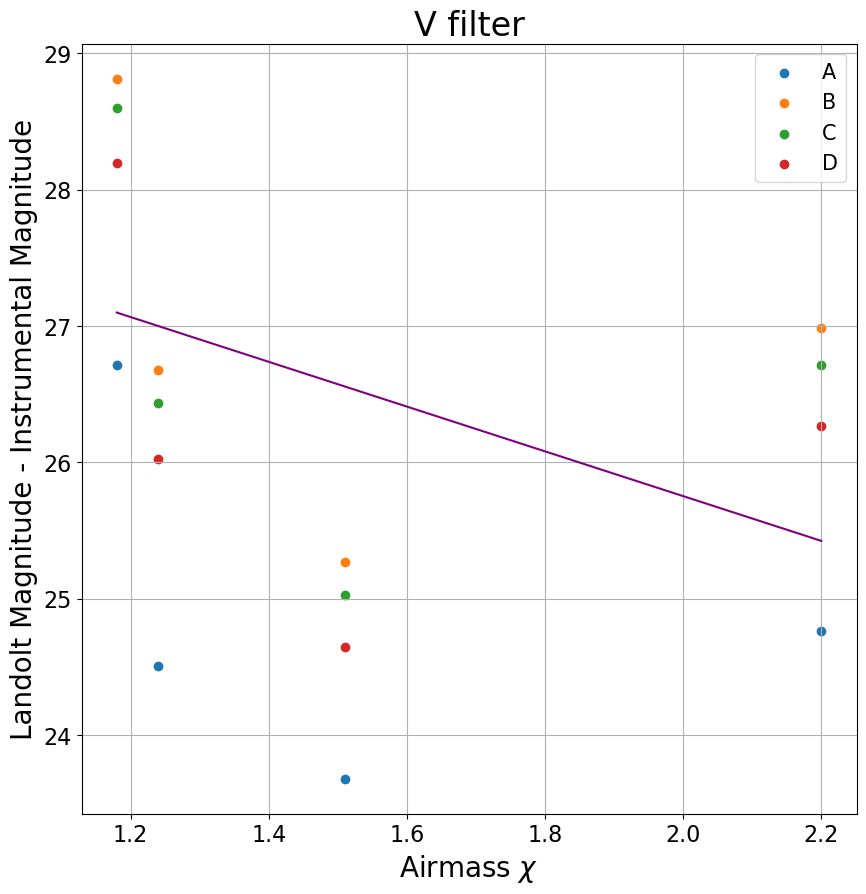

In [532]:
for i, star in enumerate(pg_files["V_inst"]):
    plt.plot(chi_vals, star, label=std_stars[i], marker="o")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Instrumental Magnitude")
plt.title("V filter")
plt.legend(fontsize=15)
plt.show()

for i, star in enumerate(pg_files["V_inst"]):
    plt.scatter(chi_vals, np.array(landolt_mag["V"])-np.array(star), label=std_stars[i], marker="o")
    m, b = np.polyfit(chi_vals, np.array(landolt_mag["V"])-np.array(star), deg=1)
    m_mean.append(m)
    b_mean.append(b)
y = np.mean(m_mean)*(chi_vals) + np.mean(b_mean)
pg_files["V_ex"].append(np.mean(m_mean))
pg_files["V_ex"].append(np.mean(b_mean))
plt.plot(chi_vals, y, color="purple")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Landolt Magnitude - Instrumental Magnitude")
plt.title("V filter")
plt.legend(fontsize=15)
plt.show()


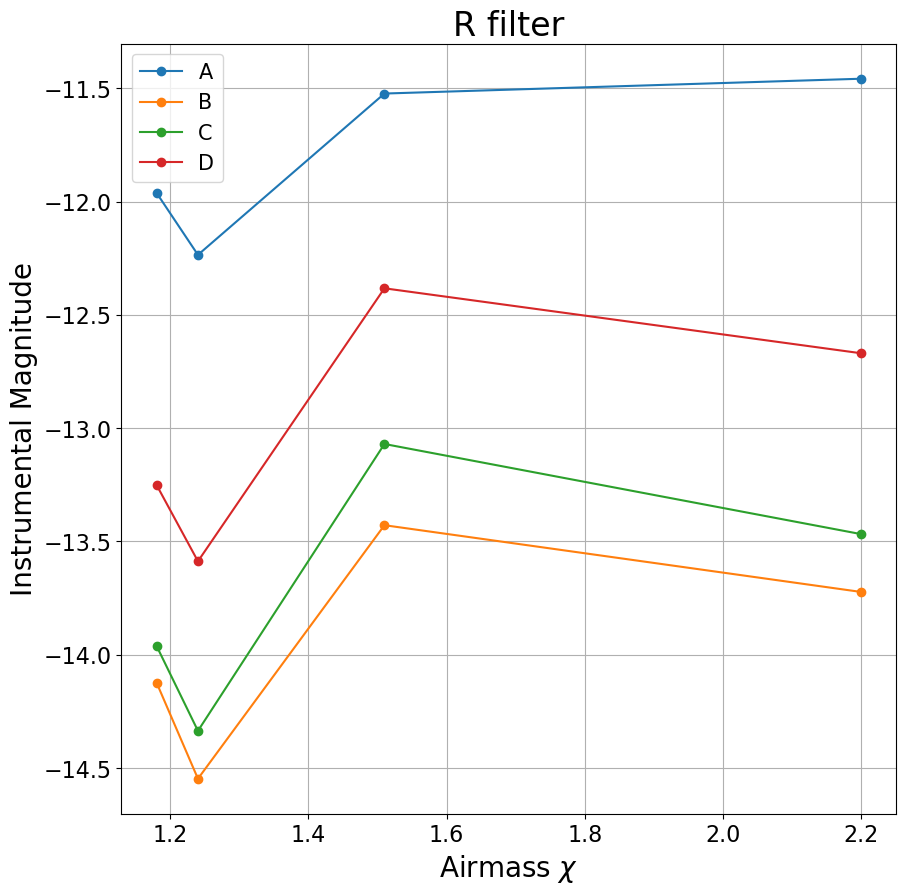

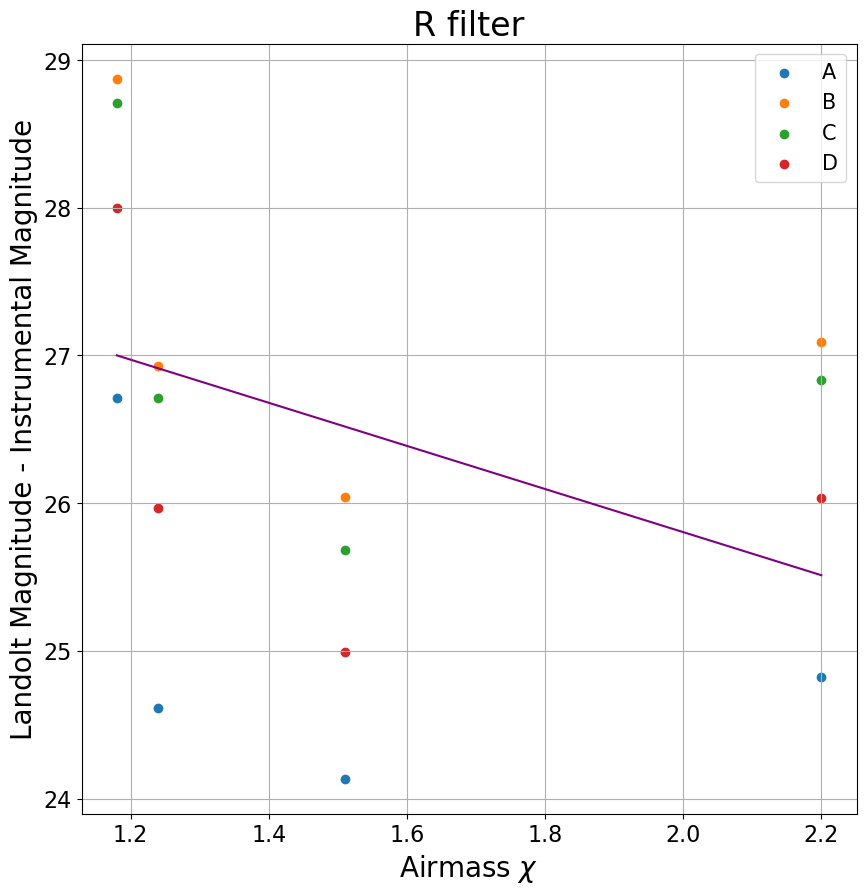

In [533]:
for i, star in enumerate(pg_files["R_inst"]):
    plt.plot(chi_vals, star, label=std_stars[i], marker="o")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Instrumental Magnitude")
plt.title("R filter")
plt.legend(fontsize=15)
plt.show()

for i, star in enumerate(pg_files["R_inst"]):
    plt.scatter(chi_vals, np.array(landolt_mag["R"])-np.array(star), label=std_stars[i], marker="o")
    m, b = np.polyfit(chi_vals, np.array(landolt_mag["R"])-np.array(star), deg=1)
    m_mean.append(m)
    b_mean.append(b)
y = np.mean(m_mean)*(chi_vals) + np.mean(b_mean)
pg_files["R_ex"].append(np.mean(m_mean))
pg_files["R_ex"].append(np.mean(b_mean))
plt.plot(chi_vals, y, color="purple")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Landolt Magnitude - Instrumental Magnitude")
plt.title("R filter")
plt.legend(fontsize=15)
plt.show()


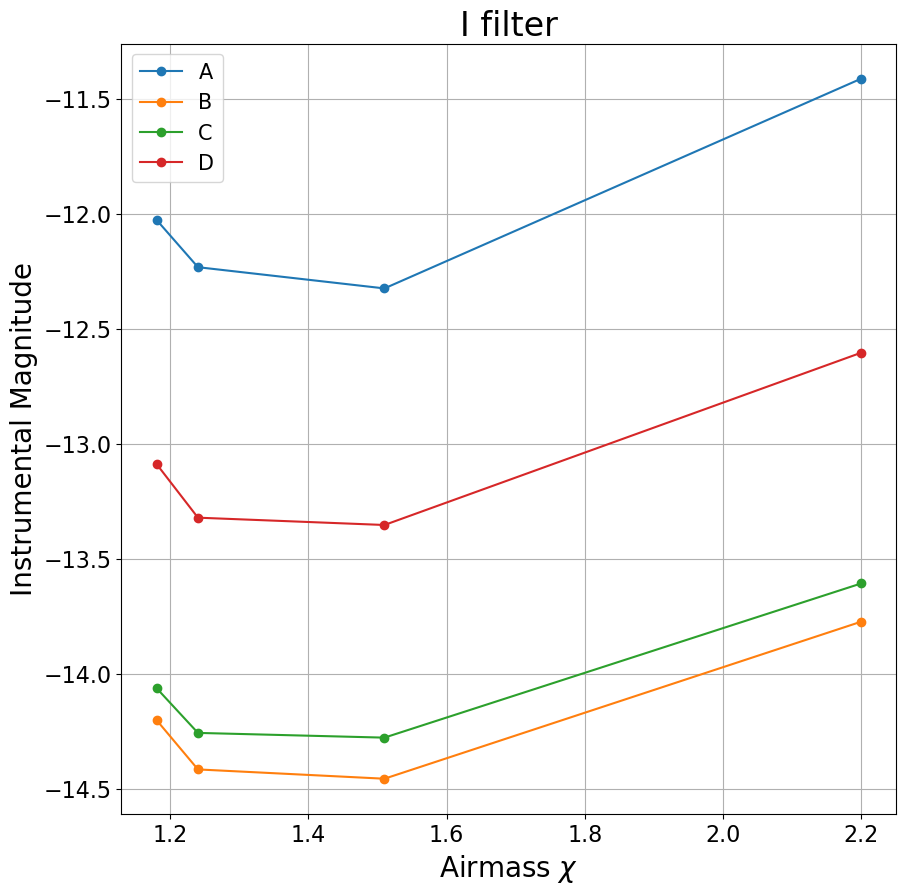

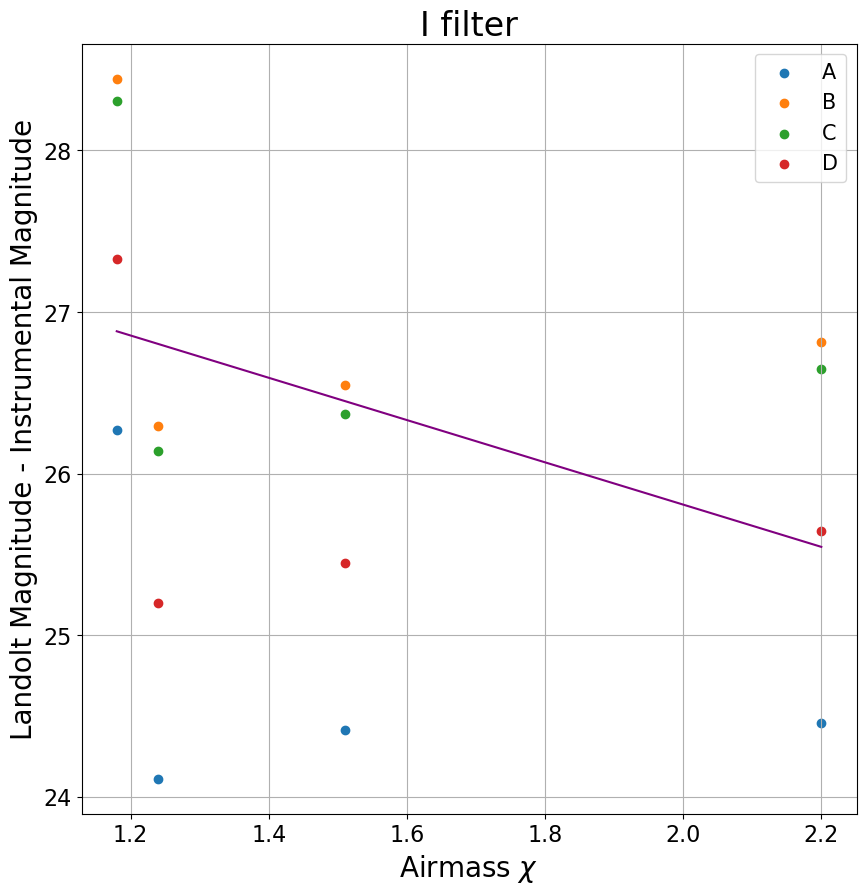

In [534]:
for i, star in enumerate(pg_files["I_inst"]):
    plt.plot(chi_vals, star, label=std_stars[i], marker="o")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Instrumental Magnitude")
plt.title("I filter")
plt.legend(fontsize=15)
plt.show()

for i, star in enumerate(pg_files["I_inst"]):
    plt.scatter(chi_vals, np.array(landolt_mag["I"])-np.array(star), label=std_stars[i], marker="o")
    m, b = np.polyfit(chi_vals, np.array(landolt_mag["I"])-np.array(star), deg=1)
    m_mean.append(m)
    b_mean.append(b)
y = np.mean(m_mean)*(chi_vals) + np.mean(b_mean)
pg_files["I_ex"].append(np.mean(m_mean))
pg_files["I_ex"].append(np.mean(b_mean))
plt.plot(chi_vals, y, color="purple")
plt.xlabel("Airmass $\chi$")
plt.ylabel("Landolt Magnitude - Instrumental Magnitude")
plt.title("I filter")
plt.legend(fontsize=15)
plt.show()

In [535]:
print(pg_files["U_ex"])
print(pg_files["B_ex"])
print(pg_files["V_ex"])
print(pg_files["R_ex"])
print(pg_files["I_ex"])

[-2.726843573992842, 29.873922759669373]
[-2.038500928947717, 29.80044012646232]
[-1.6415456123048504, 29.03575423432474]
[-1.4593506243350516, 28.72267702946754]
[-1.3077195803616362, 28.423484602526912]


## Question 6 <a class="anchor" id="q6"></a>

In [567]:
def get_delta_m(inst_val, ex_coeff, chi_val, real_val):
    return real_val - (inst_val - (ex_coeff * chi_val))

In [571]:
# extinction correction

# U
u_delta_m = []
for i, star in enumerate(pg_files["U_inst"]):
    temp = []
    for j, chi in enumerate(chi_vals):
        temp.append(get_delta_m(star[j], pg_files["U_ex"][0], chi, landolt_mag["U"][i]))
    u_delta_m.append(temp)

# B
b_delta_m = []
for i, star in enumerate(pg_files["B_inst"]):
    temp = []
    for j, chi in enumerate(chi_vals):
        temp.append(get_delta_m(star[j], pg_files["B_ex"][0], chi, landolt_mag["B"][i]))
    b_delta_m.append(temp)

# V
v_delta_m = []
for i, star in enumerate(pg_files["V_inst"]):
    temp = []
    for j, chi in enumerate(chi_vals):
        temp.append(get_delta_m(star[j], pg_files["V_ex"][0], chi, landolt_mag["V"][i]))
    v_delta_m.append(temp)

# R
r_delta_m = []
for i, star in enumerate(pg_files["R_inst"]):
    temp = []
    for j, chi in enumerate(chi_vals):
        temp.append(get_delta_m(star[j], pg_files["R_ex"][0], chi, landolt_mag["R"][i]))
    r_delta_m.append(temp)

# I
i_delta_m = []
for i, star in enumerate(pg_files["I_inst"]):
    temp = []
    for j, chi in enumerate(chi_vals):
        temp.append(get_delta_m(star[j], pg_files["I_ex"][0], chi, landolt_mag["I"][i]))
    i_delta_m.append(temp)

In [549]:
vr_val = np.array([0.505, 0.590, 0.618, 0.324])
bv_val = np.array([0.873, 1.081, 1.134, 0.535])

0.5756167233174259 21.223014389031913


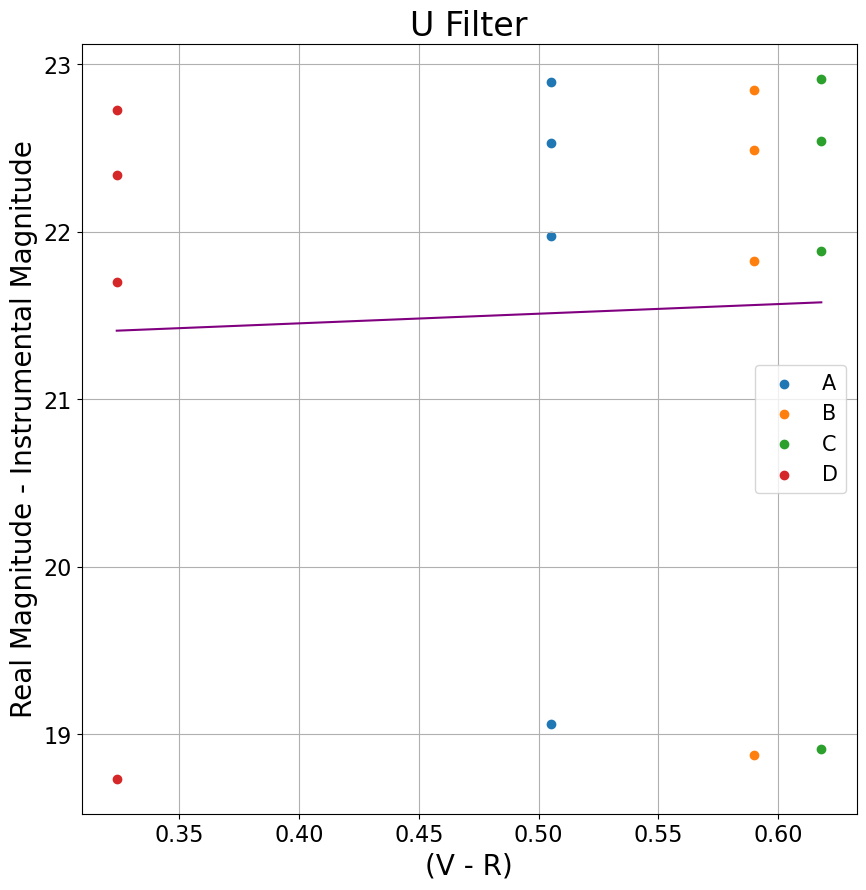

0.2651399675147762 21.2759966798048


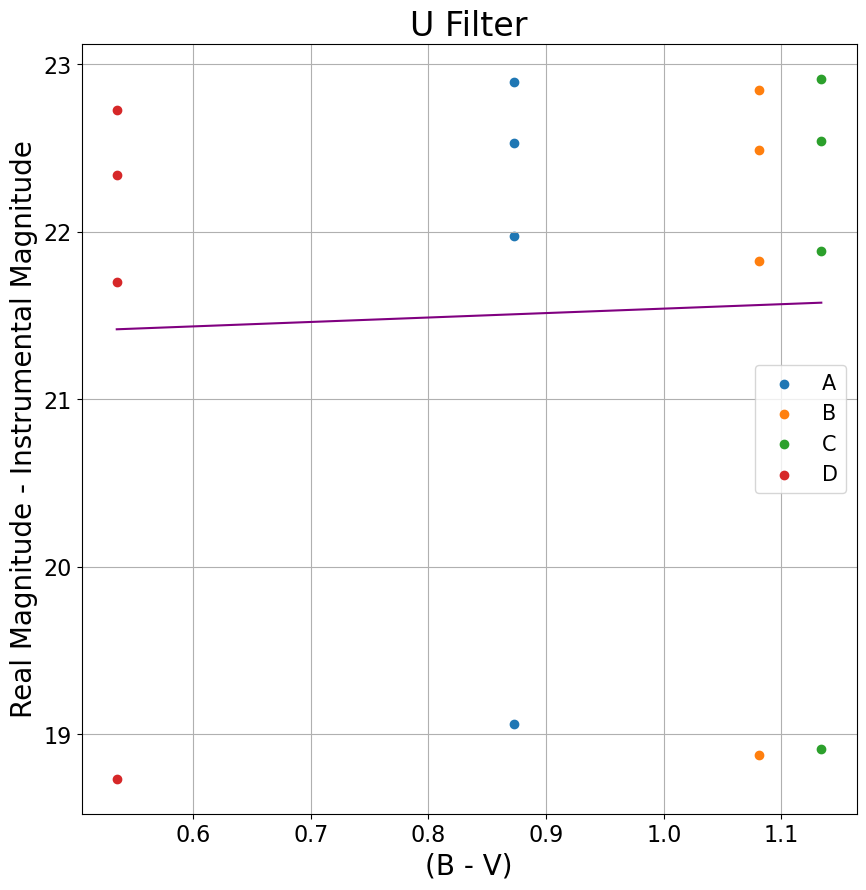

In [597]:
# U

# V - R
x = np.repeat(vr_val, 4)
y = np.array(u_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(vr_val[0]*np.ones(4), u_delta_m[0], label="A")
plt.scatter(vr_val[1]*np.ones(4), u_delta_m[1], label="B")
plt.scatter(vr_val[2]*np.ones(4), u_delta_m[2], label="C")
plt.scatter(vr_val[3]*np.ones(4), u_delta_m[3], label="D")
x_fit = np.linspace(np.min(vr_val), np.max(vr_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(V - R)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("U Filter")
plt.legend(fontsize=15)
plt.show()

# B - V
x = np.repeat(bv_val, 4)
y = np.array(u_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(bv_val[0]*np.ones(4), u_delta_m[0], label="A")
plt.scatter(bv_val[1]*np.ones(4), u_delta_m[1], label="B")
plt.scatter(bv_val[2]*np.ones(4), u_delta_m[2], label="C")
plt.scatter(bv_val[3]*np.ones(4), u_delta_m[3], label="D")
x_fit = np.linspace(np.min(bv_val), np.max(bv_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(B - V)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("U Filter")
plt.legend(fontsize=15)
plt.show()

0.34418858475299485 24.358559212776715


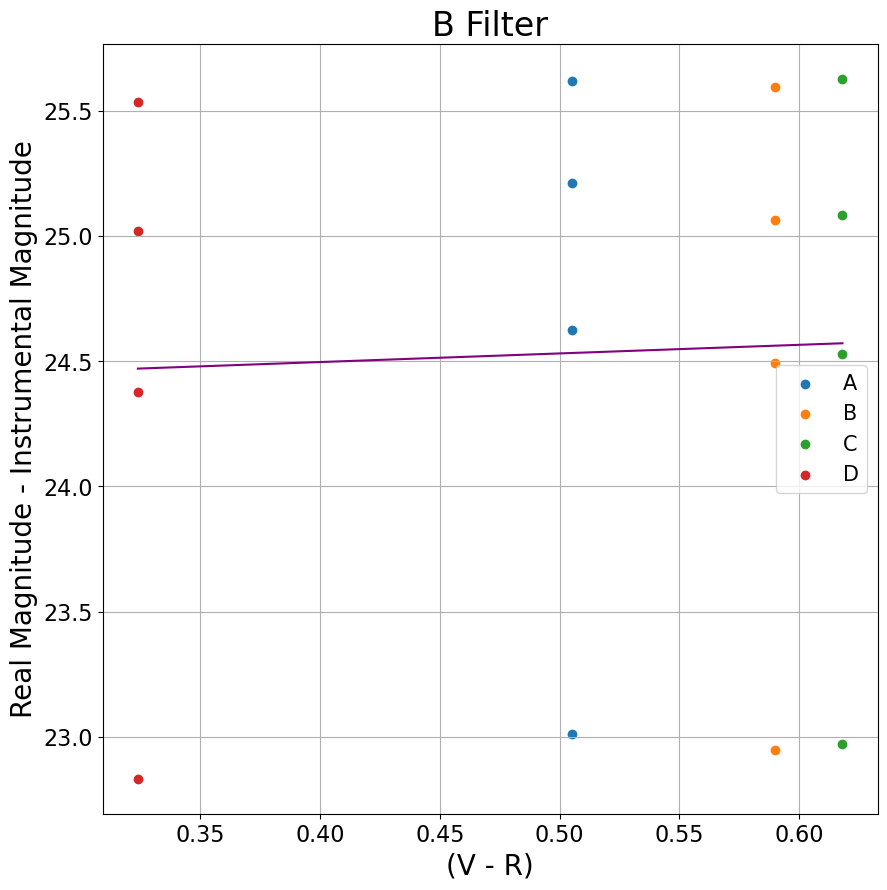

0.1551914281502362 24.39327261351508


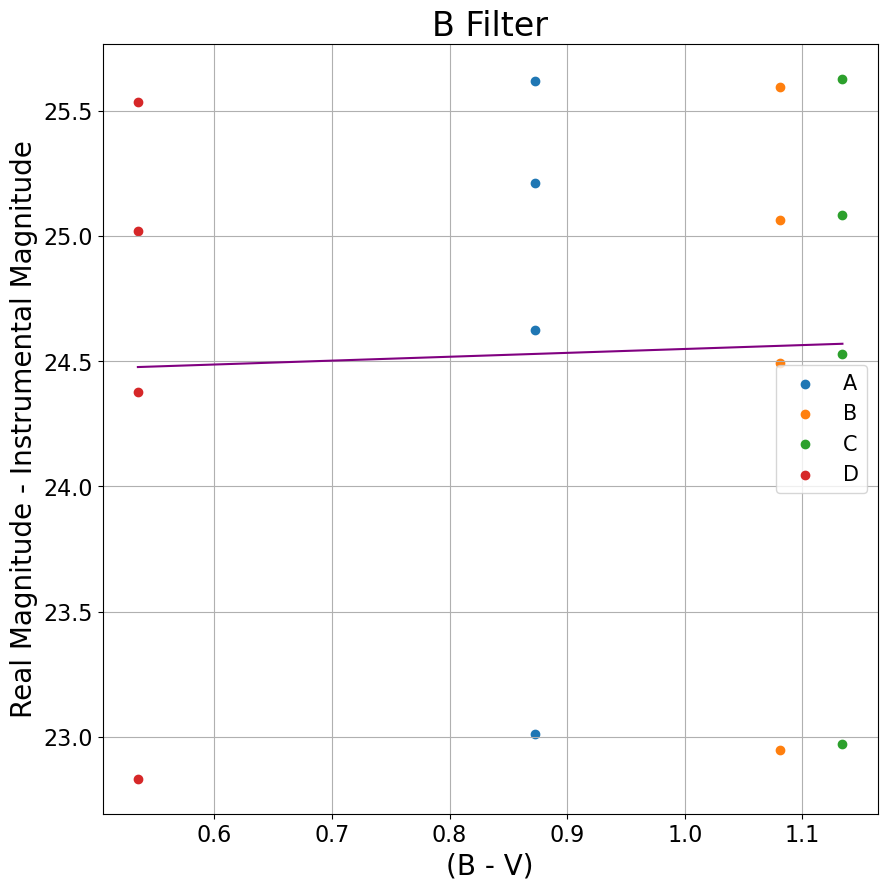

In [598]:
# B

# V - R
x = np.repeat(vr_val, 4)
y = np.array(b_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(vr_val[0]*np.ones(4), b_delta_m[0], label="A")
plt.scatter(vr_val[1]*np.ones(4), b_delta_m[1], label="B")
plt.scatter(vr_val[2]*np.ones(4), b_delta_m[2], label="C")
plt.scatter(vr_val[3]*np.ones(4), b_delta_m[3], label="D")
x_fit = np.linspace(np.min(vr_val), np.max(vr_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(V - R)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("B Filter")
plt.legend(fontsize=15)
plt.show()

# B - V
x = np.repeat(bv_val, 4)
y = np.array(b_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(bv_val[0]*np.ones(4), b_delta_m[0], label="A")
plt.scatter(bv_val[1]*np.ones(4), b_delta_m[1], label="B")
plt.scatter(bv_val[2]*np.ones(4), b_delta_m[2], label="C")
plt.scatter(bv_val[3]*np.ones(4), b_delta_m[3], label="D")
x_fit = np.linspace(np.min(bv_val), np.max(bv_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(B - V)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("B Filter")
plt.legend(fontsize=15)
plt.show()

-0.22228987881779988 23.80491431463356


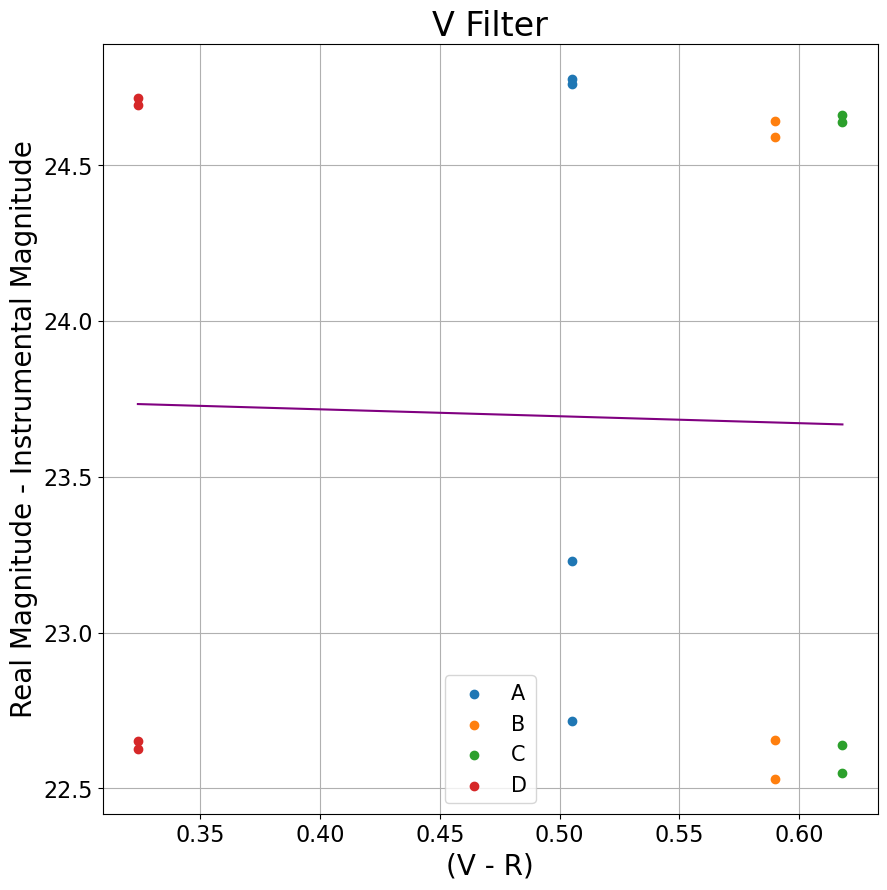

-0.1341524805477519 23.81322180310171


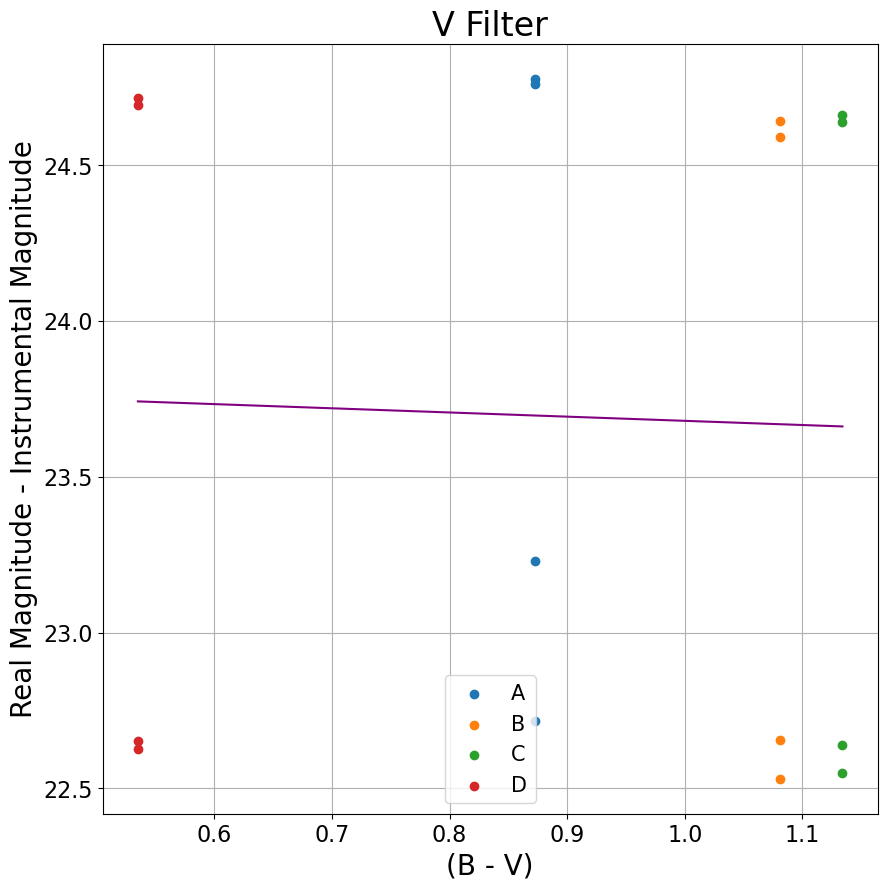

In [599]:
# V

# V - R
x = np.repeat(vr_val, 4)
y = np.array(v_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(vr_val[0]*np.ones(4), v_delta_m[0], label="A")
plt.scatter(vr_val[1]*np.ones(4), v_delta_m[1], label="B")
plt.scatter(vr_val[2]*np.ones(4), v_delta_m[2], label="C")
plt.scatter(vr_val[3]*np.ones(4), v_delta_m[3], label="D")
x_fit = np.linspace(np.min(vr_val), np.max(vr_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(V - R)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("V Filter")
plt.legend(fontsize=15)
plt.show()

# B - V
x = np.repeat(bv_val, 4)
y = np.array(v_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(bv_val[0]*np.ones(4), v_delta_m[0], label="A")
plt.scatter(bv_val[1]*np.ones(4), v_delta_m[1], label="B")
plt.scatter(bv_val[2]*np.ones(4), v_delta_m[2], label="C")
plt.scatter(bv_val[3]*np.ones(4), v_delta_m[3], label="D")
x_fit = np.linspace(np.min(bv_val), np.max(bv_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(B - V)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("V Filter")
plt.legend(fontsize=15)
plt.show()

-0.066299579626744 24.181940269425084


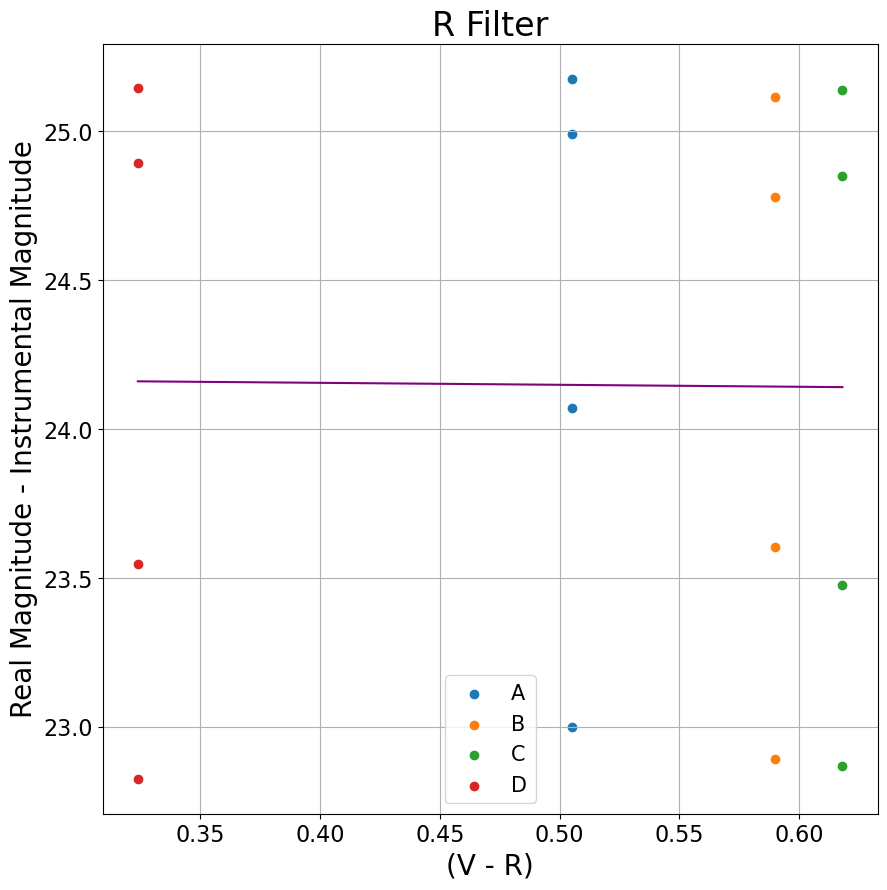

-0.055442388593619975 24.198394151968824


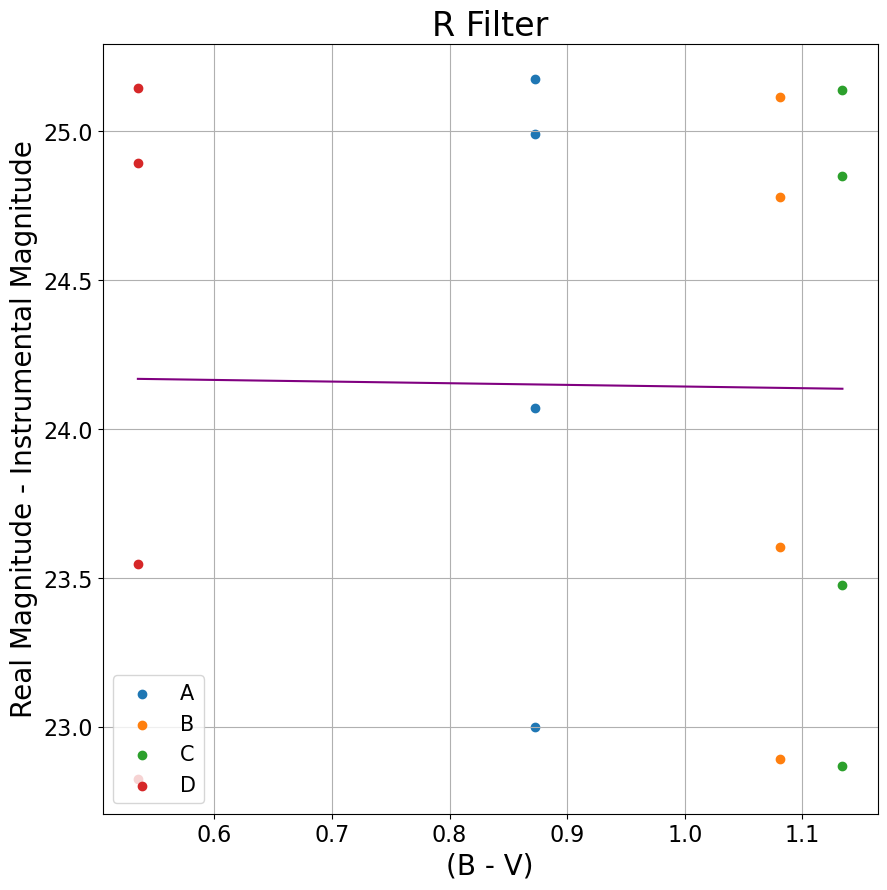

In [600]:
# R

# V - R
x = np.repeat(vr_val, 4)
y = np.array(r_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(vr_val[0]*np.ones(4), r_delta_m[0], label="A")
plt.scatter(vr_val[1]*np.ones(4), r_delta_m[1], label="B")
plt.scatter(vr_val[2]*np.ones(4), r_delta_m[2], label="C")
plt.scatter(vr_val[3]*np.ones(4), r_delta_m[3], label="D")
x_fit = np.linspace(np.min(vr_val), np.max(vr_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(V - R)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("R Filter")
plt.legend(fontsize=15)
plt.show()

# B - V
x = np.repeat(bv_val, 4)
y = np.array(r_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(bv_val[0]*np.ones(4), r_delta_m[0], label="A")
plt.scatter(bv_val[1]*np.ones(4), r_delta_m[1], label="B")
plt.scatter(bv_val[2]*np.ones(4), r_delta_m[2], label="C")
plt.scatter(bv_val[3]*np.ones(4), r_delta_m[3], label="D")
x_fit = np.linspace(np.min(bv_val), np.max(bv_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(B - V)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("R Filter")
plt.legend(fontsize=15)
plt.show()

-0.053648427010126426 24.175373141967953


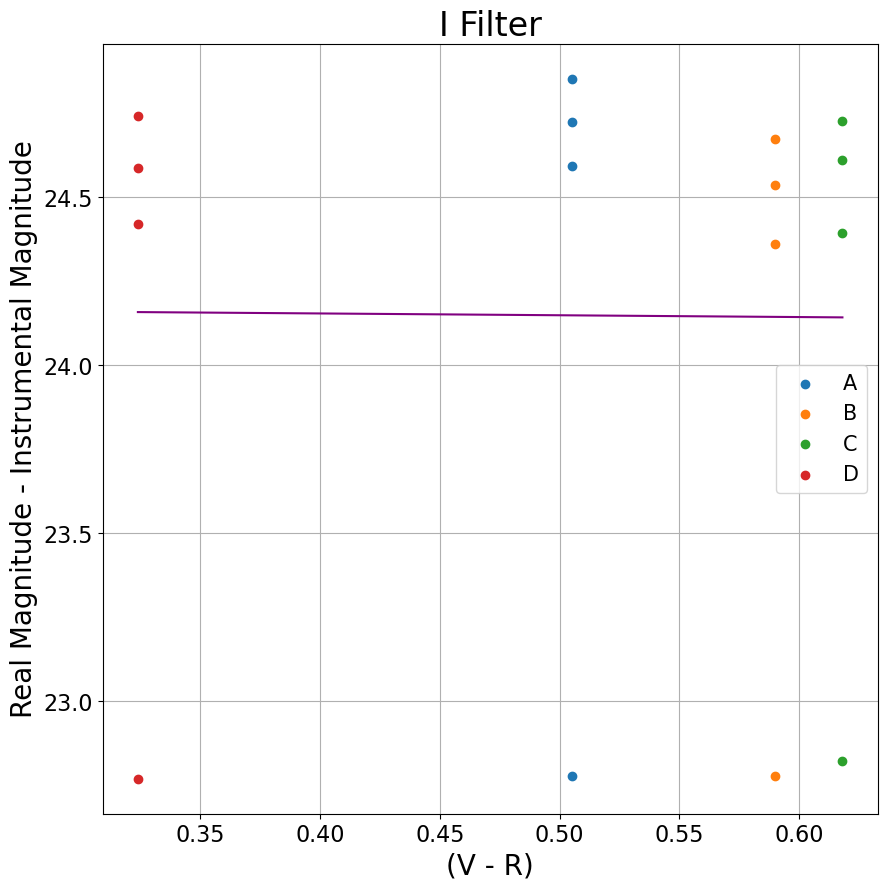

-0.03946560235978425 24.183798649850402


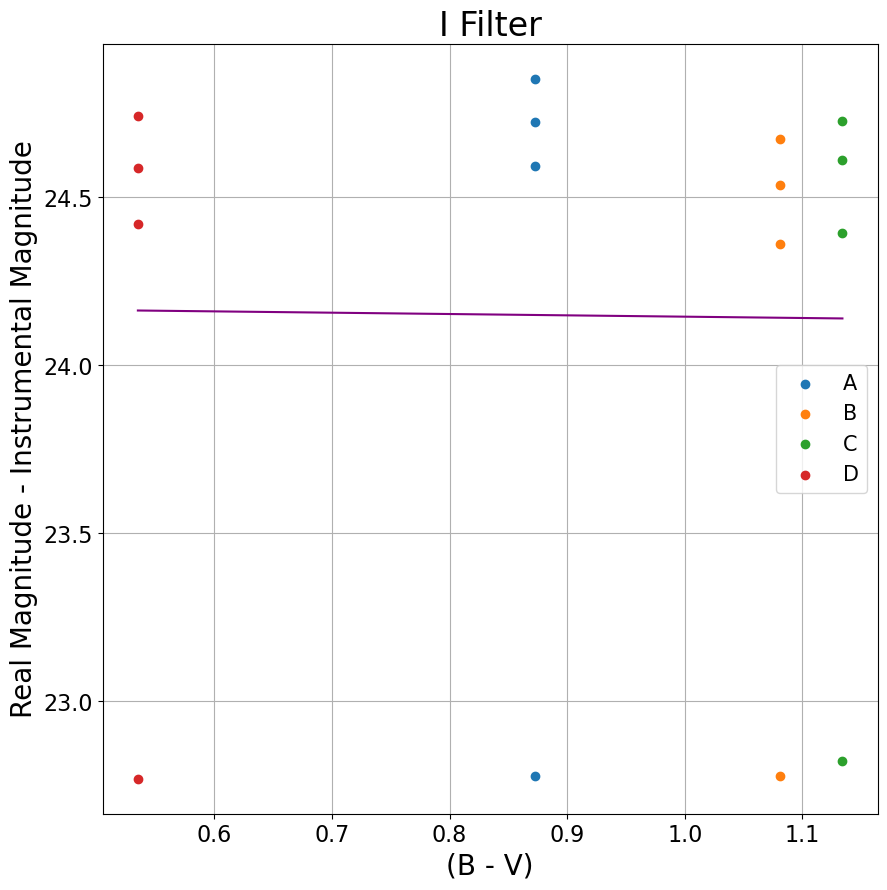

In [601]:
# I

# V - R
x = np.repeat(vr_val, 4)
y = np.array(i_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(vr_val[0]*np.ones(4), i_delta_m[0], label="A")
plt.scatter(vr_val[1]*np.ones(4), i_delta_m[1], label="B")
plt.scatter(vr_val[2]*np.ones(4), i_delta_m[2], label="C")
plt.scatter(vr_val[3]*np.ones(4), i_delta_m[3], label="D")
x_fit = np.linspace(np.min(vr_val), np.max(vr_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(V - R)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("I Filter")
plt.legend(fontsize=15)
plt.show()

# B - V
x = np.repeat(bv_val, 4)
y = np.array(i_delta_m).flatten()
m, b = np.polyfit(x, y, deg=1)
print(m, b)

plt.scatter(bv_val[0]*np.ones(4), i_delta_m[0], label="A")
plt.scatter(bv_val[1]*np.ones(4), i_delta_m[1], label="B")
plt.scatter(bv_val[2]*np.ones(4), i_delta_m[2], label="C")
plt.scatter(bv_val[3]*np.ones(4), i_delta_m[3], label="D")
x_fit = np.linspace(np.min(bv_val), np.max(bv_val), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="purple")
plt.xlabel("(B - V)")
plt.ylabel("Real Magnitude - Instrumental Magnitude")
plt.title("I Filter")
plt.legend(fontsize=15)
plt.show()

In [625]:
bv_color = np.array([(0.2651, 21.2760), (0.1552, 24.3933), (-0.1342, 23.8132), (-0.0554, 24.1984), (-0.0395, 24.1838)])

### (V-R) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 21.2230          | 0.5756                 |
| B    | 24.3586          | 0.3442                 |
| V    | 23.8049          | -0.2223                |
| R    | 24.1819          | -0.0663                |
| I    | 24.1754          | -0.0536                |

### (B-V) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 21.2760          | 0.2651                 |
| B    | 24.3933          | 0.1552                 |
| V    | 23.8132          | -0.1342                |
| R    | 24.1984          | -0.0554                |
| I    | 24.1838          | -0.0395                |

## Question 7  <a class="anchor" id="q7"></a>

In [610]:
# 12 sec exposures
# a159 - V
# a160 - B

ngc_v = ngc_files[6]
ngc_b = ngc_files[7]

v_data = fits.getdata(ngc_v)
b_data = fits.getdata(ngc_b)

_, median, std = sigma_clipped_stats(v_data, sigma=3)
daofind = DAOStarFinder(fwhm=3, threshold=5*std)
sources_v = daofind(v_data - median)

_, median, std = sigma_clipped_stats(b_data, sigma=3)
daofind = DAOStarFinder(fwhm=3, threshold=5*std)
sources_b = daofind(b_data - median)

In [611]:
pos_b = np.transpose((sources_b['xcentroid'], sources_b['ycentroid']))
pos_v = np.transpose((sources_v['xcentroid'], sources_v['ycentroid']))

matches = []
max_dist = 3.0   # pixels; adjust if needed

for i, (xB, yB) in enumerate(pos_b):
    best_j = None
    best_dist = np.inf

    for j, (xV, yV) in enumerate(pos_v):
        dist = np.sqrt((xB - xV)**2 + (yB - yV)**2)
        if dist < best_dist:
            best_dist = dist
            best_j = j

    if best_dist < max_dist:
        matches.append((i, best_j, best_dist))

print(len(matches))

pos_B_match = np.array([pos_b[i] for i, j, d in matches])
pos_V_match = np.array([pos_v[j] for i, j, d in matches])

650


In [619]:
pos_B_match[0][1]

5.861119254003226

In [ ]:
# instrumental magnitudes

v_inst_mag = []

for star in pos_V_match:
    aperture = CircularAperture(star, r=3)
    annulus = CircularAnnulus(star, r_in=25, r_out=30)
    source = aperture_photometry(data, aperture)["aperture_sum"]
    background = aperture_photometry(data, annulus)["aperture_sum"]
    v_inst_mag.append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))

v_inst_mag = np.array(v_inst_mag)

b_inst_mag = []

for star in pos_B_match:
    aperture = CircularAperture(star, r=3)
    annulus = CircularAnnulus(star, r_in=25, r_out=30)
    source = aperture_photometry(data, aperture)["aperture_sum"]
    background = aperture_photometry(data, annulus)["aperture_sum"]
    b_inst_mag.append(get_inst_mag(source[0], aperture.area, background[0], annulus.area))

b_inst_mag = np.array(b_inst_mag)

/var/folders/qv/ppt841314jl0w2nklfq529xr0000gn/T/ipykernel_9694/3250173106.py:3: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t - (a*b))
/var/folders/qv/ppt841314jl0w2nklfq529xr0000gn/T/ipykernel_9694/3250173106.py:3: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t - (a*b))
/var/folders/qv/ppt841314jl0w2nklfq529xr0000gn/T/ipykernel_9694/3250173106.py:3: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t - (a*b))
/var/folders/qv/ppt841314jl0w2nklfq529xr0000gn/T/ipykernel_9694/3250173106.py:3: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t - (a*b))
/var/folders/qv/ppt841314jl0w2nklfq529xr0000gn/T/ipykernel_9694/3250173106.py:3: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t - (a*b))
/var/folders/qv/ppt841314jl0w2nklfq529xr0000gn/T/ipykernel_9694/3250173106.py:3: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t -

In [632]:
chi_val = 1.09
star_color = ((b_inst_mag-v_inst_mag) + (bv_color[1][1]-bv_color[2][1]) + (chi_val*(pg_files["B_ex"][0]-pg_files["V_ex"][0]))) / (1 - bv_color[1][0] - bv_color[2][0])

v_calib = v_inst_mag + bv_color[2][1] + pg_files["V_ex"][0]*chi_val + bv_color[2][0]*star_color
b_calib = b_inst_mag + bv_color[1][1] + pg_files["B_ex"][0]*chi_val + bv_color[1][0]*star_color

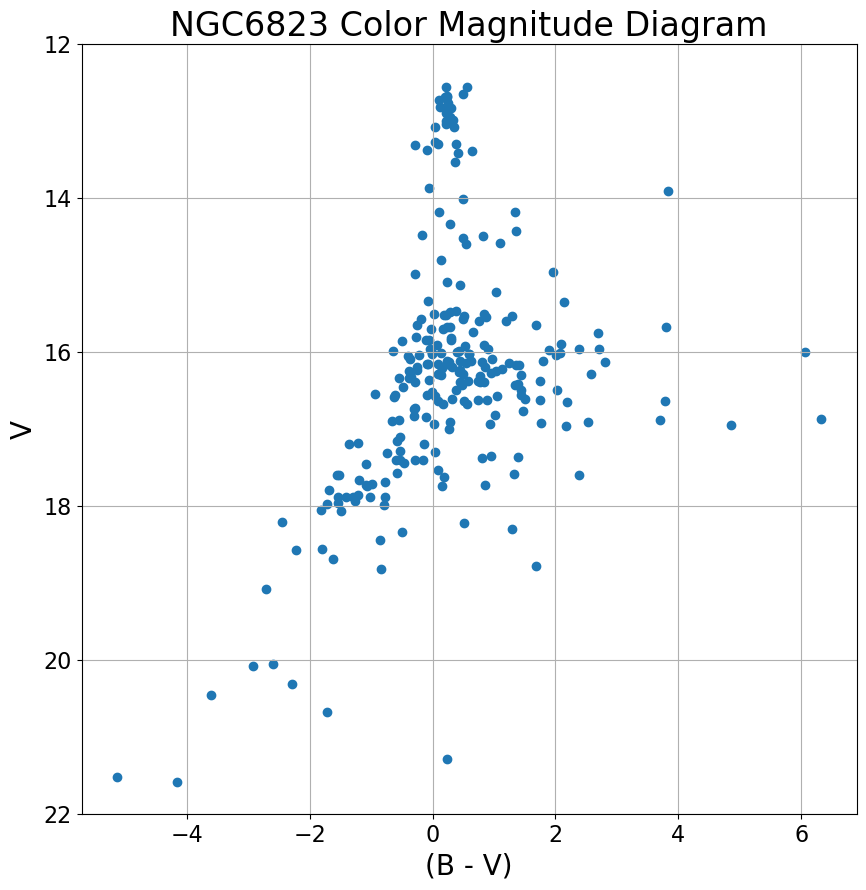

In [641]:
plt.scatter(b_calib-v_calib, v_calib)
plt.ylim(22, 12)
plt.xlabel("(B - V)")
plt.ylabel("V")
plt.title("NGC6823 Color Magnitude Diagram")
plt.show()

So clearly something went wrong. I am not sure exactly what, probably something in my instrumental magnitude calculations. It was working fine in the earlier sections, so why I got so many NaNs I have no clue. This has been a very long homework; I hope you can understand everything, Jessie.